# Entregable 1: Modelo de Estimación de Stranded Capacity en Data Centers de IA
**Proyecto No Country** | *Modelo Documentado en Notebook con Supuestos Explícitos y Fuentes Citadas*

---

## 1. Contexto y Descripción del Problema
En los Data Centers de alta densidad orientados a Inteligencia Artificial, la capacidad de cómputo está severamente limitada por el **arbitraje de energía**. La **Capacidad Varada (Stranded Capacity)** representa la potencia eléctrica contratada y pagada en Megavatios (MW) que no produce cómputo útil debido a la falta de coordinación entre la capa física (infraestructura eléctrica y térmica) y la capa operativa (orquestadores de cargas).

Este modelo implementa una estimación de rangos **determinística y auditable (Floor & Ceiling)** que permite a los operadores cuantificar el impacto económico de la capacidad varada sin revelar información confidencial.

## 2. Matriz de Supuestos Explícitos y Fuentes Citadas

### Fuentes Bibliográficas Principales:
1. **Microsoft GFS (Sankar & Vaid, 2010)**: *Trace-Driven Analysis of Data Center Power & Provisioning*. Demuestra hasta un 13% de capacidad varada por aprovisionamiento pico (Max-Power).
2. **Supermicro (2025)**: *Green Computing Benchmark Report*. Establece los PUE de referencia (1.08 en líquido vs 1.58 en aire) y el ahorro del 16% en consumo por eliminación de ventiladores IT.
3. **Uptime Institute (2024)**: *Global Data Center Survey*. PUE promedio global de 1.58 para centros por aire.
4. **U.S. Energy Information Administration (EIA, 2026)**: Tarifa comercial promedio de $0.12 USD/kWh.
5. **Nlyte Software / Colocation Index (2025/2026)**: Tarifa de oportunidad de Colocation a $184 USD/kW/mes ($2,208 USD/kW/año).

### Matriz por Tipo de Enfriamiento:
- **Aire Tradicional (`air-cooled`)**: PUE 1.58 | Stranded Capacity 12.0% - 13.0% | CAPEX $11M/MW
- **Híbrido (`hybrid`)**: PUE 1.25 | Stranded Capacity 8.0% - 10.0% | CAPEX $13.5M/MW
- **Líquido Direct-to-Chip (`liquid-cooled`)**: PUE 1.08 | Stranded Capacity 2.0% - 5.0% | CAPEX $17.5M/MW

In [4]:
from dataclasses import dataclass
from typing import Dict, Any, Literal
import matplotlib.pyplot as plt
import numpy as np

CoolingType = Literal["air-cooled", "liquid-cooled", "hybrid"]

COOLING_BENCHMARKS = {
    "air-cooled": {
        "name": "Aire Tradicional (Hot/Cold Aisle)",
        "pue_ref": 1.58,
        "stranded_pct_range": {"min": 12.0, "mid": 12.5, "max": 13.0},
        "ccf_typical": 3.9,
        "capex_per_mw": 11_000_000.0,
    },
    "liquid-cooled": {
        "name": "Líquido Direct-to-Chip / Inmersión",
        "pue_ref": 1.08,
        "stranded_pct_range": {"min": 2.0, "mid": 3.5, "max": 5.0},
        "ccf_typical": 1.2,
        "capex_per_mw": 17_500_000.0,
    },
    "hybrid": {
        "name": "Híbrido (Aire + Líquido)",
        "pue_ref": 1.25,
        "stranded_pct_range": {"min": 8.0, "mid": 9.0, "max": 10.0},
        "ccf_typical": 1.8,
        "capex_per_mw": 13_500_000.0,
    },
}

COLOCATION_RATE_PER_KW_MONTH = 184.0  # $/kW/mes
ELECTRICITY_RATE_PER_KWH = 0.12       # $/kWh
LIFECYCLE_YEARS = 4.5                 # años
HOURS_PER_YEAR = 8760
REMEDIATION_COST_PER_MW = 75_000.0     # $/MW
RECOVERABLE_FACTOR = 0.80             # 80%

class StrandedCapacityModel:
    def __init__(self, elec_rate=ELECTRICITY_RATE_PER_KWH, colo_rate=COLOCATION_RATE_PER_KW_MONTH):
        self.elec_rate = elec_rate
        self.colo_rate = colo_rate

    def estimate(self, capacity_mw: float, utilization_pct: float, cooling_type: CoolingType) -> dict:
        info = COOLING_BENCHMARKS[cooling_type]
        pct_min = info["stranded_pct_range"]["min"]
        pct_mid = info["stranded_pct_range"]["mid"]
        pct_max = info["stranded_pct_range"]["max"]

        if utilization_pct < 50.0:
            penalty = (50.0 - utilization_pct) * 0.2
            pct_mid = min(pct_max, pct_mid + penalty)

        mw_min = capacity_mw * (pct_min / 100.0)
        mw_mid = capacity_mw * (pct_mid / 100.0)
        mw_max = capacity_mw * (pct_max / 100.0)

        stranded_kw_mid = mw_mid * 1000.0

        # Floor: OPEX energico + CAPEX amortizado
        opex_energy = stranded_kw_mid * HOURS_PER_YEAR * info["pue_ref"] * self.elec_rate
        amortized_capex = (stranded_kw_mid * (info["capex_per_mw"] / 1000.0)) / LIFECYCLE_YEARS
        loss_floor = opex_energy + amortized_capex

        # Ceiling: Oportunidad Colocation
        loss_ceiling = stranded_kw_mid * self.colo_rate * 12.0
        loss_mid = (loss_floor + loss_ceiling) / 2.0

        recoverable_usd = loss_mid * RECOVERABLE_FACTOR
        remediation_cost = capacity_mw * REMEDIATION_COST_PER_MW
        roi_months = (remediation_cost / recoverable_usd * 12.0) if recoverable_usd > 0 else 0.0

        return {
            "facility_mw": capacity_mw,
            "cooling_type": cooling_type,
            "cooling_name": info["name"],
            "pue": info["pue_ref"],
            "stranded_pct_range": (pct_min, pct_mid, pct_max),
            "stranded_mw_range": (mw_min, mw_mid, mw_max),
            "loss_usd_range": (loss_floor, loss_mid, loss_ceiling),
            "recoverable_usd": recoverable_usd,
            "roi_months": roi_months,
            "usd_per_lost_mw": loss_mid / mw_mid if mw_mid > 0 else 0.0
        }

print("✅ Motor StrandedCapacityModel cargado exitosamente.")

✅ Motor StrandedCapacityModel cargado exitosamente.


## 3. Pruebas y Evaluación del Caso Base
Evaluamos un centro de datos de **15 MW** operando a una utilización promedio del **87%**, comparando las 3 arquitecturas térmicas.

In [5]:
model = StrandedCapacityModel()
facility_size = 15.0  # MW
utilization = 87.0    # 87%

results = {}
for c_type in ["air-cooled", "hybrid", "liquid-cooled"]:
    res = model.estimate(facility_size, utilization, c_type)
    results[c_type] = res
    print(f"=== {res['cooling_name']} ===")
    print(f"Stranded MW (Mid): {res['stranded_mw_range'][1]:.2f} MW ({res['stranded_pct_range'][1]}%)")
    print(f"Pérdida Financiera (Floor - Mid - Ceiling): ${res['loss_usd_range'][0]:,.2f} | ${res['loss_usd_range'][1]:,.2f} | ${res['loss_usd_range'][2]:,.2f}")
    print(f"Valor Recuperable (80%): ${res['recoverable_usd']:,.2f} USD")
    print(f"Tiempo de Recuperación ROI: {res['roi_months']:.1f} meses\n")

=== Aire Tradicional (Hot/Cold Aisle) ===
Stranded MW (Mid): 1.88 MW (12.5%)
Pérdida Financiera (Floor - Mid - Ceiling): $7,697,513.33 | $5,918,756.67 | $4,140,000.00
Valor Recuperable (80%): $4,735,005.33 USD
Tiempo de Recuperación ROI: 2.9 meses

=== Híbrido (Aire + Líquido) ===
Stranded MW (Mid): 1.35 MW (9.0%)
Pérdida Financiera (Floor - Mid - Ceiling): $5,823,900.00 | $4,402,350.00 | $2,980,800.00
Valor Recuperable (80%): $3,521,880.00 USD
Tiempo de Recuperación ROI: 3.8 meses

=== Líquido Direct-to-Chip / Inmersión ===
Stranded MW (Mid): 0.53 MW (3.5%)
Pérdida Financiera (Floor - Mid - Ceiling): $2,637,697.07 | $1,898,448.53 | $1,159,200.00
Valor Recuperable (80%): $1,518,758.83 USD
Tiempo de Recuperación ROI: 8.9 meses



## 4. Visualización Comparativa de Resultados

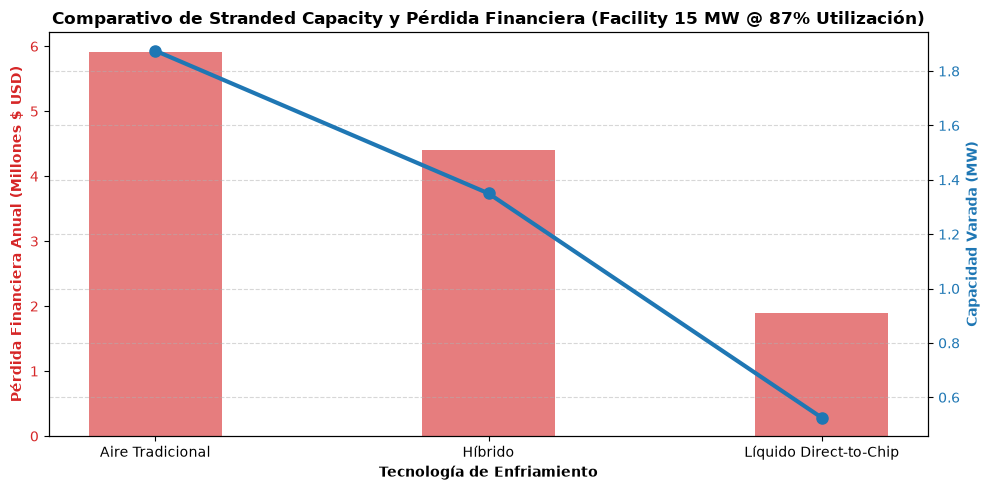

In [6]:
categories = ["Aire Tradicional", "Híbrido", "Líquido Direct-to-Chip"]
mw_vals = [results["air-cooled"]["stranded_mw_range"][1], results["hybrid"]["stranded_mw_range"][1], results["liquid-cooled"]["stranded_mw_range"][1]]
loss_mid_vals = [results["air-cooled"]["loss_usd_range"][1] / 1e6, results["hybrid"]["loss_usd_range"][1] / 1e6, results["liquid-cooled"]["loss_usd_range"][1] / 1e6]

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Tecnología de Enfriamiento', fontweight='bold')
ax1.set_ylabel('Pérdida Financiera Anual (Millones $ USD)', color=color, fontweight='bold')
bars = ax1.bar(categories, loss_mid_vals, color=color, alpha=0.6, width=0.4, label='Pérdida ($M USD)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Capacidad Varada (MW)', color=color, fontweight='bold')
lines = ax2.plot(categories, mw_vals, color=color, marker='o', linewidth=3, markersize=8, label='Stranded MW')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Comparativo de Stranded Capacity y Pérdida Financiera (Facility 15 MW @ 87% Utilización)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()